In [1]:
# import Pkg; Pkg.add("XLSX")
# import Pkg; Pkg.add("DataFrames")
# Pkg.instantiate()

In [2]:
# Trade Agreements Hypergraph Analysis

# Load required packages
using XLSX
using DataFrames

# Load the AIIRTAs.xlsx file
xlsx_file = "Trade-Agreements/AllRTAs.xlsx"
sheet = XLSX.readtable(xlsx_file, 1)  # Read the first sheet
df = DataFrame(sheet)
println(names(df))

# Filter rows where column F is "In Force"
in_force_df = filter(row -> row[:Status] == "In Force", df)

# Extract all nations from column S (semicolon-separated)
# Extract all nations from column "Current signatories" (semicolon-separated)
# Extract all nations from column "Current signatories" (semicolon-separated)
all_nations = String[]
for row in eachrow(in_force_df)
    nations = split(strip(row[:CurrentSignatories]), ';')
    append!(all_nations, strip.(nations))
end
unique_nations = sort(unique(all_nations))

# Map each nation to an integer
nation_to_idx = Dict(nation => idx for (idx, nation) in enumerate(unique_nations))

# Build hypergraph: each agreement is a hyperedge (list of nation indices)
hyperedges = Vector{Vector{Int}}()
for row in eachrow(in_force_df)
    nations = split(strip(row[:CurrentSignatories]), ';')
    indices = [nation_to_idx[strip(n)] for n in nations]
    push!(hyperedges, indices)
end

# Save nation mapping to a txt file
open("Trade-Agreements/nation_mapping.txt", "w") do io
    for (nation, idx) in nation_to_idx
        println(io, "$idx\t$nation")
    end
end

println("Saved nation mapping to Trade-Agreements/nation_mapping.txt")

# Build hypergraph: each agreement is a hyperedge (list of nation indices)
hyperedges = Vector{Vector{Int}}()
for row in eachrow(in_force_df)
    nations = split(strip(row[:CurrentSignatories]), ';')
    indices = [nation_to_idx[strip(n)] for n in nations]
    push!(hyperedges, indices)
end

println("Total hyperedges (agreements): ", length(hyperedges))
println("Total unique nations: ", length(unique_nations))

# Print first few hyperedges
println("First few hyperedges:")
for i in 1:min(10, length(hyperedges))
    println("  Hyperedge $i: $(hyperedges[i])")
end

# For compatibility with later code, treat each hyperedge as a "simplex"
simplices = hyperedges

# Create simple simplex structure for processing (no timestamps or sizes needed)
temporal_simplices = [simplices[i] for i in 1:length(simplices)]

println("Created hypergraph with ", length(temporal_simplices), " simplices")

# Basic statistics
println("Number of nodes: ", length(unique_nations))
println("\nReady for tensor creation!")



["RTA ID", "RTA Name", "Coverage", "Type", "Notification", "Status", "Date of Signature (G)", "Date of Signature (S)", "Date of Notification (G)", "Date of Notification (S)", "Date of Entry into Force (G)", "Date of Entry into Force (S)", "Inactive Date", "Accession?", "RTA Composition", "Region", "Cross-regional", "All Parties WTO members?", "CurrentSignatories", "Original signatories", "Specific Entry/Exit dates", "WTO Consideration Process (G)", "Consideration Date (G)", "WTO Consideration Process (S)", "Consideration Date (S)", "End of implementation period (G)", "End of implementation period (S)", "Remarks"]
Saved nation mapping to Trade-Agreements/nation_mapping.txt
Total hyperedges (agreements): 401
Total unique nations: 224
First few hyperedges:
  Hyperedge 1: [4, 6, 26, 33, 36, 34, 39, 41, 46, 47, 55, 63, 67, 57, 78, 200, 81, 86, 54, 106, 116, 117, 124, 127, 129, 130, 137, 138, 140, 149, 150, 87, 168, 175, 177, 179, 180, 186, 224, 221, 66, 201, 204, 209, 61, 198, 32, 223]
  Hy

In [3]:
# Load Dleto for chiselling analysis
using Pkg
Pkg.activate("../")
using Dleto
using ITensors
using Statistics
using Plots

# Create a 3-mode tensor by decomposing hyperedges into 3-node subsets
println("Creating 3-mode tensor from hyperedge decomposition...")

n_nodes = length(unique_nations)
node_to_idx = nation_to_idx

println("Tensor dimensions:")
println("  Node 1: $n_nodes")
println("  Node 2: $n_nodes")
println("  Node 3: $n_nodes")
println("  Total entries: $(n_nodes^3)")
println("  Using nodes: $(minimum(values(node_to_idx))) to $(maximum(values(node_to_idx)))")

function get_3node_combinations(nodes)
    if length(nodes) < 3
        return []
    elseif length(nodes) == 3
        return [nodes]
    else
        combinations = []
        for i in 1:length(nodes)-2
            for j in i+1:length(nodes)-1
                for k in j+1:length(nodes)
                    push!(combinations, [nodes[i], nodes[j], nodes[k]])
                end
            end
        end
        return combinations
    end
end


  Activating project at `c:\Users\AVM11\GitHub\OpenDleto`


WebIO._IJuliaInit()

Loading Dleto Plots Extension
Creating 3-mode tensor from hyperedge decomposition...
Tensor dimensions:
  Node 1: 224
  Node 2: 224
  Node 3: 224
  Total entries: 11239424
  Using nodes: 1 to 224


get_3node_combinations (generic function with 1 method)

In [4]:

# Create ITensor indices for the 3-mode tensor
i = Index(n_nodes, "node1")
j = Index(n_nodes, "node2")
k = Index(n_nodes, "node3")

Triangles = ITensor(Float32, i, j, k)

processed_simplices = 0
total_triangles = 0
skipped_small = 0

for simplex in temporal_simplices
    triangle_combinations = get_3node_combinations(simplex)
    if isempty(triangle_combinations)
        skipped_small += 1
        continue
    end
    for triangle in triangle_combinations
        node_indices = triangle
        if length(node_indices) == 3
            a, b, c = node_indices[1], node_indices[2], node_indices[3]
            Triangles[i=>a, j=>b, k=>c] += 1.0
            Triangles[i=>a, j=>c, k=>b] += 1.0
            Triangles[i=>b, j=>a, k=>c] += 1.0
            Triangles[i=>b, j=>c, k=>a] += 1.0
            Triangles[i=>c, j=>a, k=>b] += 1.0
            Triangles[i=>c, j=>b, k=>a] += 1.0
            total_triangles += 1
        end
    end
    processed_simplices += 1
end

T_array = Array(Triangles, i, j, k)
non_zero_entries = count(x -> x != 0, T_array)
total_entries = length(T_array)

println("✅ 3-mode triangle tensor created!")
println("Processed simplices: $processed_simplices")
println("Skipped simplices (< 3 nodes): $skipped_small")
println("Total triangles extracted: $total_triangles")
println("Non-zero tensor entries: $non_zero_entries / $total_entries")
println("Sparsity: $(round((total_entries - non_zero_entries) / total_entries * 100, digits=1))%")
println("Max triangle count: $(Int(maximum(T_array)))")
println("Mean triangle count: $(round(mean(T_array[T_array .> 0]), digits=2))")


✅ 3-mode triangle tensor created!
Processed simplices: 83
Skipped simplices (< 3 nodes): 318
Total triangles extracted: 50949
Non-zero tensor entries: 217212 / 11239424
Sparsity: 98.1%
Max triangle count: 9
Mean triangle count: 1.41


┌ Warning: More than 1,000 viewable entries, plotting only the largest points.
└ @ DletoPlotsExt c:\Users\AVM11\GitHub\OpenDleto\ext\DletoPlotsExt.jl:257


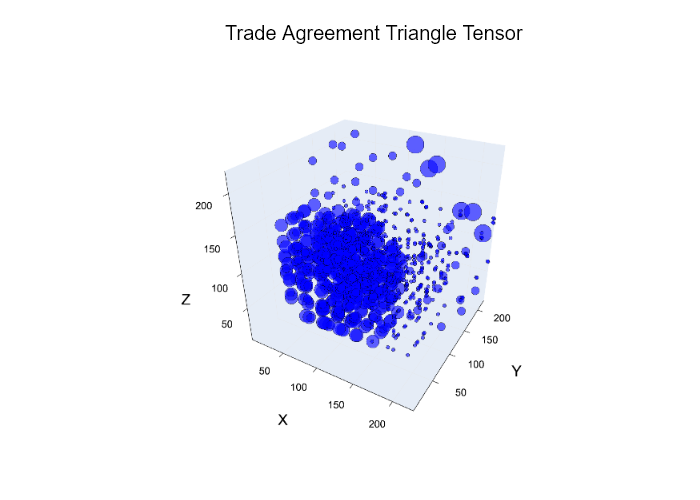

In [5]:

# Plot the tensor using Dleto's plotting function
plot_tensor(Triangles, title="Trade Agreement Triangle Tensor")


In [6]:

# Create a subsample tensor for faster processing (e.g., first 80 nations if enough)
max = min(120, n_nodes)
# max= n_nodes
i_small = Index(max, "node1_small")
j_small = Index(max, "node2_small")
k_small = Index(max, "node3_small")

SmallTrade = ITensor(i_small, j_small, k_small)
T_small_array = T_array[1:max, 1:max, 1:max]

for a in 1:max, b in 1:max, c in 1:max
    if T_small_array[a, b, c] != 0
        SmallTrade[i_small=>a, j_small=>b, k_small=>c] = T_small_array[a, b, c]
    end
end

small_non_zero = count(x -> x != 0, T_small_array)
small_total = length(T_small_array)

println("✅ Subsample tensor created!")

# Perform stratified decomposition on the subsample
println("\n🔬 Performing stratified decomposition on SmallTrade tensor...")
@time SmallTrade_strat, Xs_strat_small = stratify(SmallTrade);

println("✅ SmallTrade stratification complete!")


✅ Subsample tensor created!

🔬 Performing stratified decomposition on SmallTrade tensor...
Using SVDSolver...
Converting LinearMap to Matrix for SVD...
24832.523617 seconds (7.54 G allocations: 9.675 TiB, 2.08% gc time, 0.14% compilation time)


[ Info: Found 10 derivations for stratification.


✅ SmallTrade stratification complete!


┌ Warning: More than 1,000 viewable entries, plotting only the largest points.
└ @ DletoPlotsExt c:\Users\AVM11\GitHub\OpenDleto\ext\DletoPlotsExt.jl:257
┌ Warning: More than 1,000 viewable entries, plotting only the largest points.
└ @ DletoPlotsExt c:\Users\AVM11\GitHub\OpenDleto\ext\DletoPlotsExt.jl:257


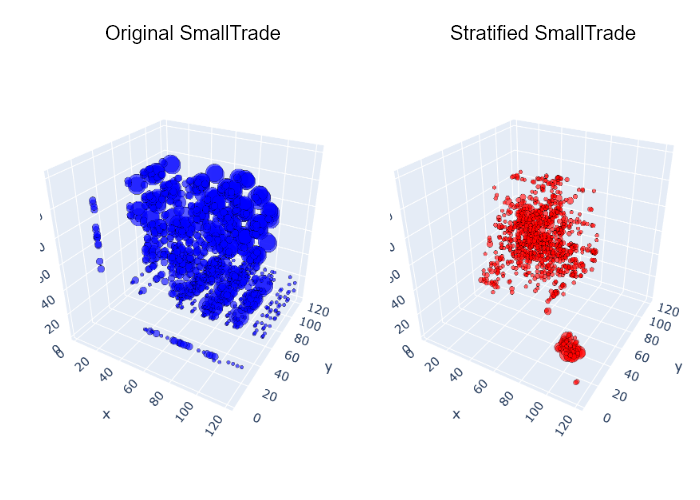

In [7]:

# Plot SmallTrade and SmallTrade_strat side by side
p1 = plot_tensor(SmallTrade; title="Original SmallTrade", color=:blue)
p2 = plot_tensor(SmallTrade_strat; title="Stratified SmallTrade", color=:red)
Plots.plot(p1, p2; layout=(1,2), size=(800,400))


In [8]:

# Analyze the stratified results - Node position patterns (SmallTrade subsample)
println("\n🎯 Analyzing node position patterns in SmallTrade triangles...")

node1_1 = ITensor(i_small); node1_1[i_small=>1] = 1.0;
node1_operator_idx = 0
for (idx, X) in enumerate(Xs_strat_small)
    if i_small in inds(X)
        node1_operator_idx = idx
        break
    end
end

if node1_operator_idx > 0
    mix_node1_1 = Xs_strat_small[node1_operator_idx] * node1_1
    mix_node1_1_array = Array(mix_node1_1, inds(mix_node1_1))
    println("Node 1 in first position - stratified representation:")
    for (idx, weight) in enumerate(mix_node1_1_array)
        if abs(weight) > 1e-6
            println("  $(round(weight*100, digits=1))% × stratified coordinate $idx")
        end
    end
else
    println("Could not find first node position operator in stratification")
end



🎯 Analyzing node position patterns in SmallTrade triangles...
Node 1 in first position - stratified representation:
  4.8% × stratified coordinate 1
  -4.6% × stratified coordinate 2
  2.3% × stratified coordinate 3
  0.4% × stratified coordinate 4
  2.3% × stratified coordinate 5
  1.4% × stratified coordinate 6
  1.5% × stratified coordinate 7
  1.6% × stratified coordinate 8
  0.3% × stratified coordinate 9
  0.2% × stratified coordinate 10
  -0.3% × stratified coordinate 11
  1.3% × stratified coordinate 12
  0.2% × stratified coordinate 13
  0.4% × stratified coordinate 14
  0.1% × stratified coordinate 15
  -0.7% × stratified coordinate 16
  -3.1% × stratified coordinate 17
  -0.5% × stratified coordinate 18
  2.6% × stratified coordinate 19
  -1.4% × stratified coordinate 20
  -2.2% × stratified coordinate 21
  -2.4% × stratified coordinate 22
  -2.0% × stratified coordinate 23
  5.3% × stratified coordinate 24
  -3.9% × stratified coordinate 25
  -0.7% × stratified coordinate 

In [9]:

# Analyze second and third node position patterns (SmallTrade subsample)
println("\n🔄 Analyzing second and third node positions...")

node2_1 = ITensor(j_small); node2_1[j_small=>1] = 1.0;
node2_operator_idx = 0
for (idx, X) in enumerate(Xs_strat_small)
    if j_small in inds(X)
        node2_operator_idx = idx
        break
    end
end

if node2_operator_idx > 0
    mix_node2_1 = Xs_strat_small[node2_operator_idx] * node2_1
    mix_node2_1_array = Array(mix_node2_1, inds(mix_node2_1))
    println("Node 1 in second position - stratified representation:")
    for (idx, weight) in enumerate(mix_node2_1_array)
        if abs(weight) > 1e-6
            println("  $(round(weight*100, digits=1))% × stratified coordinate $idx")
        end
    end
end

node3_1 = ITensor(k_small); node3_1[k_small=>1] = 1.0;
node3_operator_idx = 0
for (idx, X) in enumerate(Xs_strat_small)
    if k_small in inds(X)
        node3_operator_idx = idx
        break
    end
end

if node3_operator_idx > 0
    mix_node3_1 = Xs_strat_small[node3_operator_idx] * node3_1
    mix_node3_1_array = Array(mix_node3_1, inds(mix_node3_1))
    println("\nNode 1 in third position - stratified representation:")
    for (idx, weight) in enumerate(mix_node3_1_array)
        if abs(weight) > 1e-6
            println("  $(round(weight*100, digits=1))% × stratified coordinate $idx")
        end
    end
end

println("\n✅ SmallTrade 3-mode hypergraph tensor analysis complete!")
println("Data structures available:")
println("- Triangles: Full 3-mode tensor of triangle counts")
println("- SmallTrade: Subsample tensor")
println("- SmallTrade_strat: Stratified subsample tensor")
println("- Xs_strat_small: Transverse operators for SmallTrade")
println("- temporal_simplices: Original hypergraph data (list of node vectors)")


🔄 Analyzing second and third node positions...
Node 1 in second position - stratified representation:
  -10.4% × stratified coordinate 1
  -39.0% × stratified coordinate 2
  -36.1% × stratified coordinate 3
  16.3% × stratified coordinate 4
  -59.2% × stratified coordinate 5
  -20.0% × stratified coordinate 6
  -1.4% × stratified coordinate 7
  54.5% × stratified coordinate 8
  -30.6% × stratified coordinate 9
  0.2% × stratified coordinate 10
  46.5% × stratified coordinate 11
  -66.5% × stratified coordinate 12
  3.0% × stratified coordinate 13
  -53.7% × stratified coordinate 14
  -50.5% × stratified coordinate 15
  -1.7% × stratified coordinate 16
  -31.3% × stratified coordinate 17
  4.6% × stratified coordinate 18
  -25.8% × stratified coordinate 19
  -39.9% × stratified coordinate 20
  -17.6% × stratified coordinate 21
  2.7% × stratified coordinate 22
  -18.4% × stratified coordinate 23
  12.1% × stratified coordinate 24
  29.4% × stratified coordinate 25
  3.6% × stratified c